<a href="https://colab.research.google.com/github/parika8ec-hub/DataScience_Project_BIA/blob/Assignment8/Assignment8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task-1: Dataset Selection and Preprocessing

For this project, the Breast Cancer Wisconsin (Diagnostic) dataset from the sklearn library was selected. This dataset is widely used in machine learning for classification problems, particularly in the medical field. It contains features computed from digitized images of breast mass cell nuclei, which describe characteristics such as radius, texture, perimeter, area, smoothness and symmetry.

The main objective of this dataset is to classify tumors as either malignant (cancerous) or benign (non-cancerous) based on these features. This makes it a binary classification problem, which is suitable for evaluating and comparing different machine learning models.

The dataset is well-structured, clean, and does not contain missing values, making it ideal for preprocessing, exploratory data analysis, and model building. It also provides a meaningful real-world application, helping to demonstrate how machine learning can be used in healthcare for early disease detection and diagnosis.





In [1]:
#Import libraries
from sklearn.datasets import load_breast_cancer
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [2]:
#Load dataset from sklearn library
data = load_breast_cancer()
#Convert data into dataframe
cancer_data = pd.DataFrame(data.data, columns=data.feature_names)
cancer_data['target'] = data.target #add target column

#Display few rows of dataset
print('Few Rows of Dataset:\n',cancer_data.head())

Few Rows of Dataset:
    mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst 

In [3]:
print('Information of dataset:')
print(cancer_data.info())

Information of dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  sm

In [4]:
print('Description of dataset:')
print(cancer_data.describe().round(2))

Description of dataset:
       mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
count       569.00        569.00          569.00     569.00           569.00   
mean         14.13         19.29           91.97     654.89             0.10   
std           3.52          4.30           24.30     351.91             0.01   
min           6.98          9.71           43.79     143.50             0.05   
25%          11.70         16.17           75.17     420.30             0.09   
50%          13.37         18.84           86.24     551.10             0.10   
75%          15.78         21.80          104.10     782.70             0.11   
max          28.11         39.28          188.50    2501.00             0.16   

       mean compactness  mean concavity  mean concave points  mean symmetry  \
count            569.00          569.00               569.00         569.00   
mean               0.10            0.09                 0.05           0.18   
std               

In [5]:
# Missing values check
print('Missing values:\n',cancer_data.isnull().sum())

# Remove duplicates from dataset
cancer_data = cancer_data.drop_duplicates()

#Select features and target values
X = cancer_data.drop('target', axis=1)#take independent variables
y = cancer_data['target']#take target variable

#Split data into training(80%) and testing(20%) set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Missing values:
 mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


# Task-2: Exploratory Data Analysis (EDA)

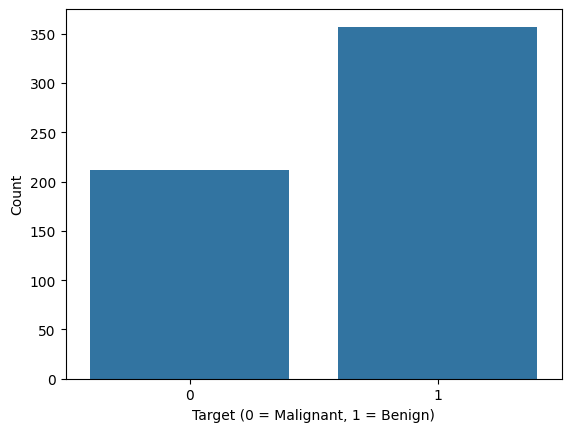

In [13]:
#Create count plot for classes
sns.countplot(x=y)
#Add title and label of axis
plt.xlabel("Target (0 = Malignant, 1 = Benign)")#add label as 0= Malignant(cancerous) and 1=Benign(non-cancerous)
plt.ylabel("Count")
plt.show()#display plot

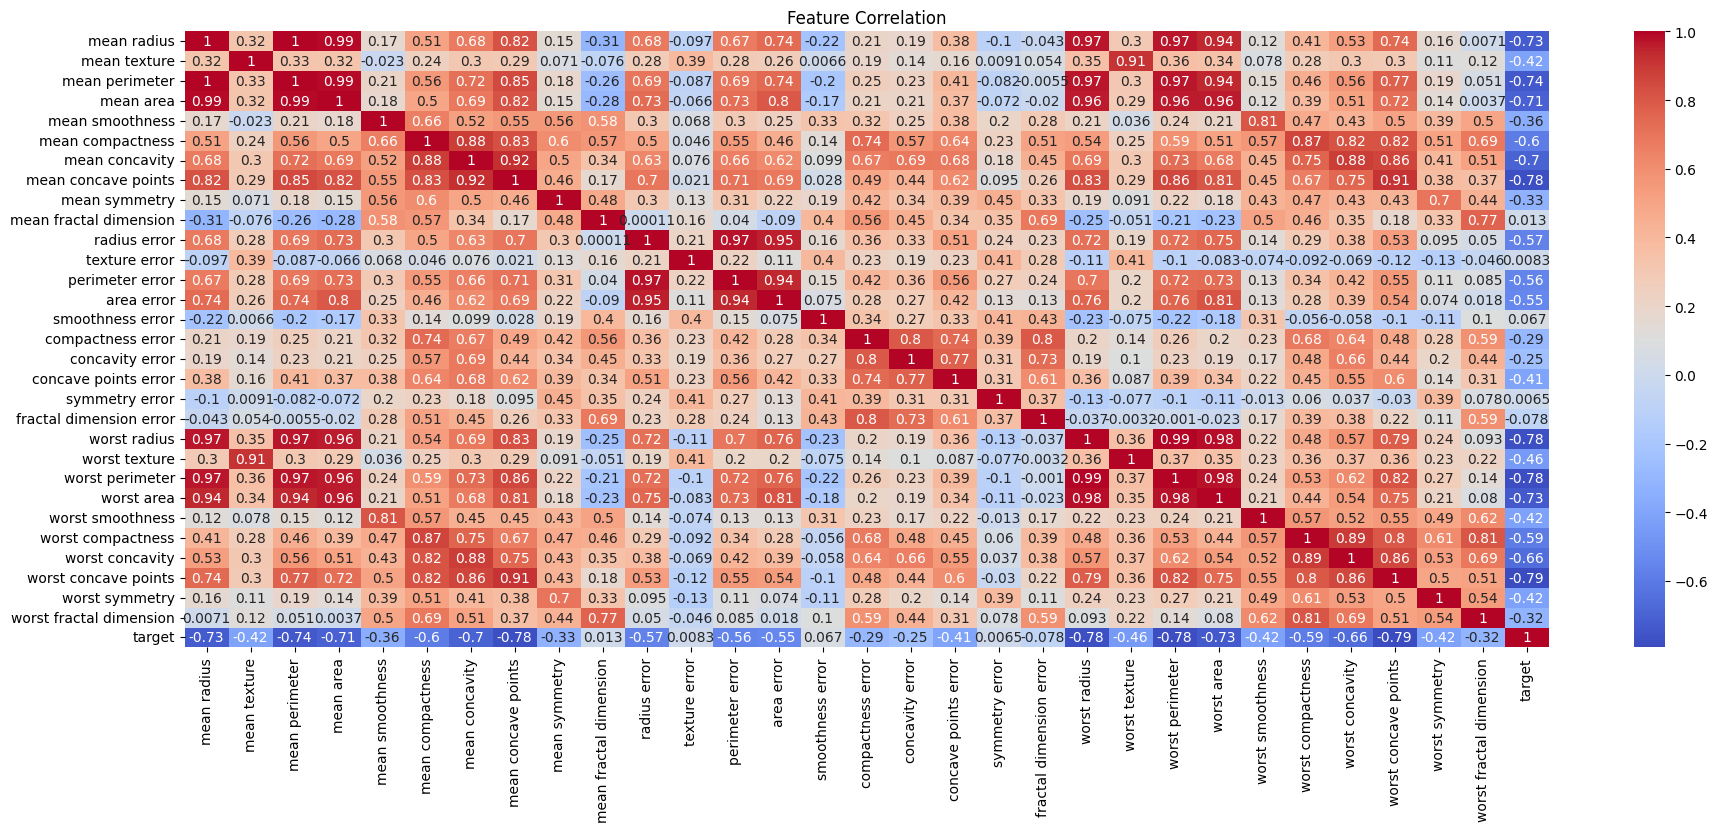

In [7]:
plt.figure(figsize=(22,8))#set plot size
sns.heatmap(cancer_data.corr(), annot=True,cmap='coolwarm')#create heatmap to see the relationship between variables using correlation value
plt.title("Feature Correlation")#add title
plt.show()#display plot

# Key Observations from Correlation Heatmap


*   Many features like mean radius, mean perimeter and mean area are highly correlated (more than 0.9) that indicates multicollinearity.
*   Worst features like worst radius, worst perimeter etc. are also strongly correlated with target and strong predictors.
*   Some features have negative correlation with target, meaning they help distinguish malignant vs benign.

# Impact on Model Choice

The high correlation among features indicates that tree-based models like Random Forest are better suited for handling this dataset, as they can manage multicollinearity effectively and capture complex feature interactions. In contrast, linear models such as Logistic Regression may be slightly affected by highly correlated variables, but they still perform well due to the strong underlying patterns present in the data. Additionally, since all features are numerical and properly scaled, both models are able to train efficiently and achieve strong predictive performance.


# Task-3: Model Implementation and Evaluation

In [8]:
#Initialize Logistic Regression Model
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)#fit model on training data
y_pred_log = log_model.predict(X_test)#predict value on testing data

#Calculate evaluation matrix as accuracy, precision,recall and f1 sccore on test data
print("Logistic Regression Accuracy:", round(accuracy_score(y_test, y_pred_log),2))
print("Precision:", round(precision_score(y_test, y_pred_log),2))
print("Recall:", round(recall_score(y_test, y_pred_log),2))
print("F1:", round(f1_score(y_test, y_pred_log),2))

Logistic Regression Accuracy: 0.96
Precision: 0.95
Recall: 0.99
F1: 0.97


# Interpretation:

Logistic regression shows very high recall (0.99) means almost all cancer cases are correctly identified and slightly lower precision means few false positives.This works well because data is almost linearly separable.

In [9]:
#Initialize Random Forest Classifier Model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)#fit model on training data
y_pred_rf = rf_model.predict(X_test)#predict value on testing data

#Calculate evaluation matrix as accuracy, precision,recall and f1 sccore on test data
print("Random Forest Accuracy:", round(accuracy_score(y_test, y_pred_rf),2))
print("Precision:", round(precision_score(y_test, y_pred_rf),2))
print("Recall:", round(recall_score(y_test, y_pred_rf),2))
print("F1:", round(f1_score(y_test, y_pred_rf),2))

Random Forest Accuracy: 0.96
Precision: 0.96
Recall: 0.99
F1: 0.97


# Interpretation:

Random Forest Classifier performs equally well as Logistic Regression.It handles feature interactions means non-linearity better and slightly better precision shows fewer false positives.

In [10]:
#Calculate AUC for both model
print("Logistic AUC:", round(roc_auc_score(y_test, log_model.predict_proba(X_test)[:,1]),2))
print("RF AUC:", round(roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]),2))

Logistic AUC: 1.0
RF AUC: 1.0



# Task-4: Model Interpretation and Inference

# Model Comparison:

Both models perform almost identically, achieving an AUC score of 1.0, which indicates excellent classification performance. However, Random Forest is slightly preferred because it can effectively handle highly correlated features and capture complex, non-linear relationships within the data. On the other hand, Logistic Regression is simpler, faster and easier to interpret, making it valuable when model transparency is important. Therefore, while Random Forest is better suited for maximizing performance, Logistic Regression remains a strong choice for interpretability and simplicity.


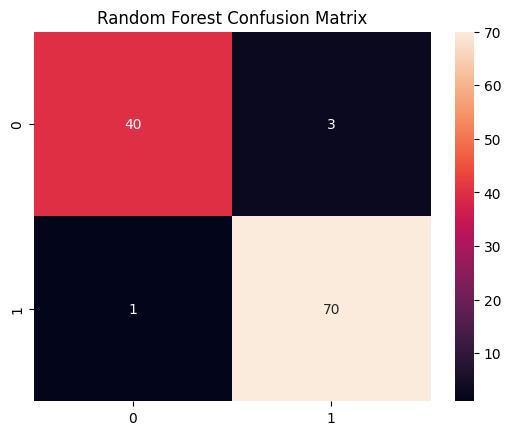

In [11]:
#Create heatmap based on calculated confusion matrix of random forest classfier model
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")#add title
plt.show()#display plot

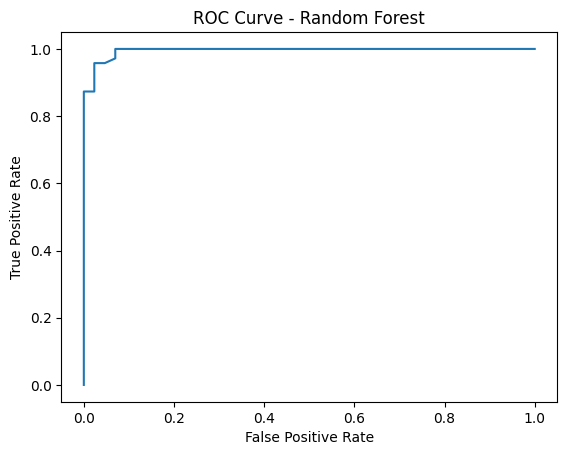

In [12]:
#Calculate FPR (False Positive Rate) and TPR (True Positive Rate / Recall)
fpr, tpr, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:,1])
plt.plot(fpr, tpr)#create line plot
#Add title and label of axis
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()#display plot

# Conclusion:

The dataset shows strong feature correlations and clear class separability, which contributes to high model performance. Both Logistic Regression and Random Forest achieved excellent results with an AUC score of 1.0, indicating perfect classification capability. Random Forest slightly outperforms Logistic Regression due to its ability to handle feature interactions and multicollinearity. The class distribution is slightly imbalanced but does not negatively impact model performance, as evidenced by high recall and F1 scores.

# Task-5: Deployment and Monitoring

# Model Deployment

The best-performing model (Random Forest) can be deployed in a production environment using a REST API. This can be achieved by saving the trained model using libraries like joblib or pickle, and then integrating it into a web framework such as Flask or FastAPI. The API can receive input data, preprocess it and return predictions in real time. The deployed model can be hosted on cloud platforms like AWS or Google Cloud for scalability and accessibility.

# Potential Issues During Deployment

Several challenges may arise during model deployment and operation. One major issue is data drift, where incoming real-time data differs from the training data, leading to reduced model accuracy. Additionally, real-world data may contain missing or noisy values, which can negatively impact predictions. Latency issues may also occur, where slow response times affect the overall user experience. Over time, model performance may degrade as underlying data patterns change. To handle real-time data effectively, it is important to apply the same preprocessing steps used during training, validate input data before making predictions, and use pipelines to ensure consistency and reliability in the prediction process.

# Monitoring and Maintenance

To ensure long-term model performance, continuous monitoring is essential. This involves regularly tracking key performance metrics such as accuracy, precision and recall to detect any decline in prediction quality over time. It is also important to monitor the input data to identify any changes in its distribution, which may indicate data drift. A proper retraining strategy should be implemented, where the model is periodically updated using new and relevant data to maintain its effectiveness. Additionally, maintaining logs of predictions and errors helps in debugging and understanding model behavior. Setting up automated alerts can further assist in quickly identifying performance drops, enabling timely intervention and ensuring the model remains reliable in a production environment.